**Import Libraries**

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


**Import Data Set**

In [3]:
goldData=pd.read_csv('/content/Gold vs USDINR.csv')

**Data Analysis**

In [4]:
goldData.head()

,Date,USD_INR,Goldrate
0,1/1/2024,83.240601,"5,066.31"
1,1/8/2024,83.076103,"4,966.31"
2,1/15/2024,83.160599,"5,015.33"
3,1/22/2024,83.146103,"4,950.84"
4,1/29/2024,82.927597,"4,976.77"


In [5]:
#Replace thousand separator and change the data type to float
goldData['Goldrate']=goldData['Goldrate'].str.replace(',','').astype(float)

In [6]:
goldData.head()

,Date,USD_INR,Goldrate
0,1/1/2024,83.240601,5066.31
1,1/8/2024,83.076103,4966.31
2,1/15/2024,83.160599,5015.33
3,1/22/2024,83.146103,4950.84
4,1/29/2024,82.927597,4976.77


In [9]:
#Change the date into yyyy/MM/dd format
goldData['Date']=pd.to_datetime(goldData['Date'],format='%m/%d/%Y')
goldData['Date']=goldData['Date'].dt.strftime('%Y/%m/%d')
goldData.head()

,Date,USD_INR,Goldrate
0,2024/01/01,83.240601,5066.31
1,2024/01/08,83.076103,4966.31
2,2024/01/15,83.160599,5015.33
3,2024/01/22,83.146103,4950.84
4,2024/01/29,82.927597,4976.77


Exploratory Data Analysis

*1. Handling Missing Values*

In [10]:
goldData.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53 entries, 0 to 52
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Date      53 non-null     object 
 1   USD_INR   53 non-null     float64
 2   Goldrate  53 non-null     float64
dtypes: float64(2), object(1)
memory usage: 1.4+ KB


*2. Handle Outliers*

<Axes: ylabel='USD_INR'>

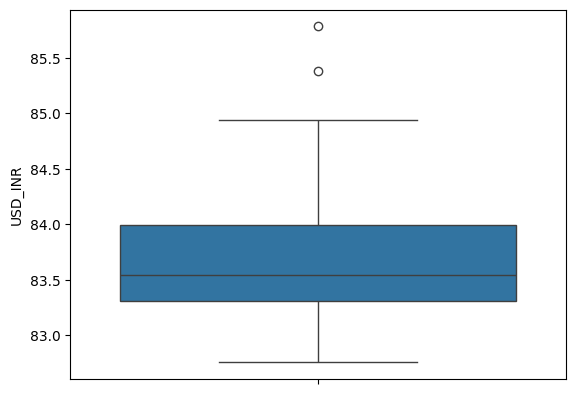

In [11]:
sns.boxplot(goldData['USD_INR'])

In [12]:
goldData['USD_INR'].max()

85.78659821

In [13]:
goldData['USD_INR'].min()

82.75229645

<Axes: xlabel='USD_INR', ylabel='Goldrate'>

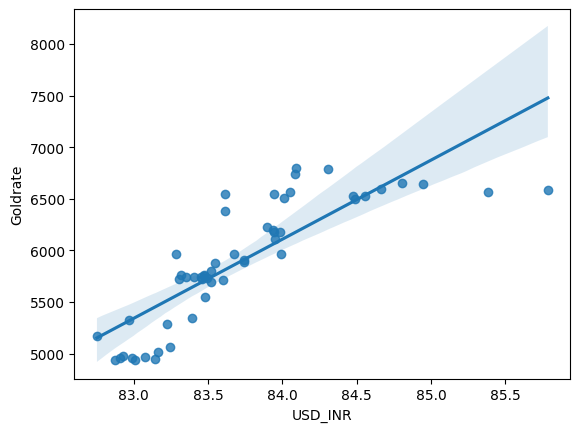

In [14]:
sns.regplot(y='Goldrate',x='USD_INR',data=goldData)


**Model Training**

In [15]:
x=goldData[['USD_INR']]
y=goldData[['Goldrate']]

In [16]:
x

,USD_INR
0,83.240601
1,83.076103
2,83.160599
3,83.146103
4,82.927597
5,82.985298
6,83.009598
7,82.872299
8,82.910400
9,82.752296


*Split Dataset*

In [17]:
import numpy as np
from sklearn.model_selection import train_test_split

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.1, random_state=42)

In [20]:
X_train.shape,X_test.shape

((47, 1), (6, 1))

*Standardization*

In [21]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [22]:
X_train_scaled

array([[-0.4753469 ],
       [ 1.91603897],
       [-0.87974106],
       [ 0.36700952],
       [-0.36423189],
       [-1.24606136],
       [-0.33998365],
       [-1.09189238],
       [ 0.28432837],
       [-1.21933493],
       [-0.15146399],
       [-0.17182302],
       [ 0.92354506],
       [ 0.35503362],
       [ 1.69379708],
       [-0.25979254],
       [-1.49178076],
       [-0.63775672],
       [ 0.04932799],
       [ 0.34602205],
       [-0.40604082],
       [-0.7546344 ],
       [-0.7328762 ],
       [ 1.20624748],
       [-0.30097304],
       [ 0.43025651],
       [ 0.461963  ],
       [ 0.05011057],
       [ 1.18371856],
       [-0.98853205],
       [-0.60807784],
       [-0.85721215],
       [ 0.36342862],
       [ 0.42186152],
       [-0.29537637],
       [ 1.48242836],
       [-1.16027359],
       [-0.371536  ],
       [-0.39283176],
       [ 3.22402082],
       [-0.66169667],
       [-1.30527686],
       [ 0.57448905],
       [-0.56394486],
       [-0.05883454],
       [ 2

In [23]:
X_test_scaled

array([[-0.37619593],
       [ 0.53097266],
       [ 1.31302272],
       [-0.49602609],
       [ 0.58955971],
       [-1.12965796]])

In [24]:
from sklearn.linear_model import LinearRegression
regressor=LinearRegression()
regressor.fit(X_train_scaled,y_train)

LinearRegression()

In [25]:
regressor.get_params()

{'copy_X': True, 'fit_intercept': True, 'n_jobs': None, 'positive': False}

In [26]:
regressor.coef_

array([[469.20755762]])

In [27]:
regressor.intercept_

array([5878.57340426])

In [28]:
#y=mx+c
m=regressor.coef_[0][0]
c=regressor.intercept_[0]
print(m,c)
#

469.2075576153299 5878.573404255313


In [29]:
X_train_Predict=regressor.predict(X_train_scaled)
X_test_Predict=regressor.predict(X_test_scaled)

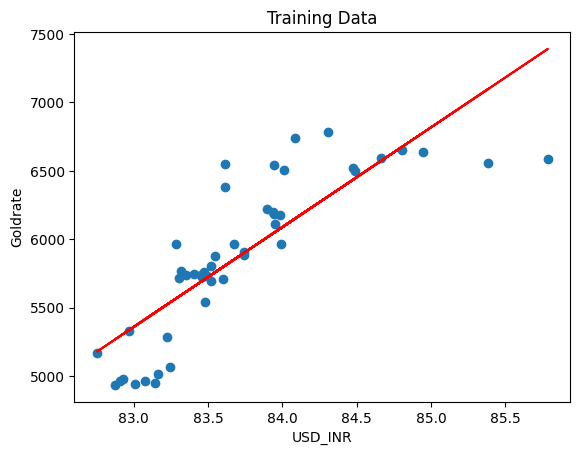

In [30]:
plt.scatter(X_train,y_train)
plt.plot(X_train,X_train_Predict,color='red')
plt.xlabel('USD_INR')
plt.ylabel('Goldrate')
plt.title('Training Data')
plt.show()

*Find Mean Squared Error (MSE)*

In [31]:
from sklearn.metrics import mean_squared_error

In [34]:
mean_squared_error(y_test,X_test_Predict)


141948.22993388725

**Hyperparameter Tuning**

In [39]:
from sklearn.model_selection import RandomizedSearchCV
param_space={'copy_X':[True,False],
             'fit_intercept':[True,False],
             'n_jobs':[1,5,10,None],
             'positive':[True,False]
             }

In [40]:
search=RandomizedSearchCV(regressor,param_space,n_iter=50,cv=5)
search.fit(X_train,y_train)

RandomizedSearchCV(cv=5, estimator=LinearRegression(), n_iter=50,
                   param_distributions={'copy_X': [True, False],
                                        'fit_intercept': [True, False],
                                        'n_jobs': [1, 5, 10, None],
                                        'positive': [True, False]})

In [41]:
search.best_params_

{'positive': True, 'n_jobs': 1, 'fit_intercept': True, 'copy_X': True}

In [42]:
tuned_regressor=LinearRegression(copy_X=True,fit_intercept=True,n_jobs=1,positive=True)

In [43]:
tuned_regressor.fit(X_train_scaled,y_train)

LinearRegression(n_jobs=1, positive=True)

In [44]:
tuned_regressor.coef_

array([[469.20755762]])

In [45]:
tuned_regressor.intercept_

array([5878.57340426])

**MLOPs**

*Save the model*

In [46]:
import pickle

In [47]:
pickle.dump(tuned_regressor,open('regressor.pkl','wb'))

In [48]:
regressor_reloaded=pickle.load(open('regressor.pkl','rb'))

In [49]:
regressor_reloaded.coef_

array([[469.20755762]])

In [50]:
pickle.dump(scaler,open('scaler.pkl','wb'))

*Build Interface*

In [73]:
def CalculateGoldRate(usd):
  scaled_input=scaler.transform(np.array(usd).reshape(1,-1))
  gold_rate=regressor.predict(scaled_input)[0][0].round(2)
  return gold_rate

In [74]:
CalculateGoldRate(80)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


np.float64(3171.57)

In [57]:
import gradio as gr

In [75]:
demo = gr.Interface(
    fn=CalculateGoldRate,
    inputs=["number"],
    outputs=["number"],
    title="Gold Rate Calculator",
    description="Enter the USD rate and get the predicted Gold Rate in INR"
)

demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://8d1a4a3a3812f26717.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
